In [ ]:
# IROS optimisation by hand - SCOX-1

from singleCAM_IROS._pipeline_support import _handle_dirpaths

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.coords import shift2pos, shift2angle, angle2shift, equatorial2shift
from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask, count, decode
from bloodmoon.optim import model_sky as bm_sky

import darksun as ds
from darksun.data import DataLoader, CatalogueLoader

from fract_shift2 import model_shadowgram


def extract_catalogue_angular_coords(
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
) -> pd.DataFrame:
    """
    """
    s, txs, tys = [], [], []
    for sourceID in np.unique(catalogue.DLdata['ID']):
        source = catalogue.DLdata[(catalogue.DLdata['ID'] == sourceID)]
        sx, sy = equatorial2shift(sdl, camera, source['RA'], source['DEC'])
        thetax, thetay = map(lambda x: shift2angle(wfm, x), (sx, sy))
        s.append(sourceID)
        txs.append(thetax)
        tys.append(thetay)

    df = pd.DataFrame(
        {'ID': s, 'THETAX': txs, 'THETAY': tys}
    )
    return df

def model_sky(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    fluence: float,
    vignetting: bool = True,
    psfy: bool = True,
) -> NDArray:
    """
    Generate a model of the reconstructed sky image for a point source.
    """
    decoded = decode(
        camera=camera,
        detector=model_shadowgram(
            camera, shift_x, shift_y, vignetting=vignetting, psfy=psfy,
        ),
    )
    return decoded * fluence


skyfield = "GalacticCentre"
mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_infdet_2-50keV_1ks"

mask_path, simul_data, _ = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)

source_ID = 'scox1'


SCOX-1 angular coords: (np.float64(12.202274809914625), np.float64(21.025135698738143))



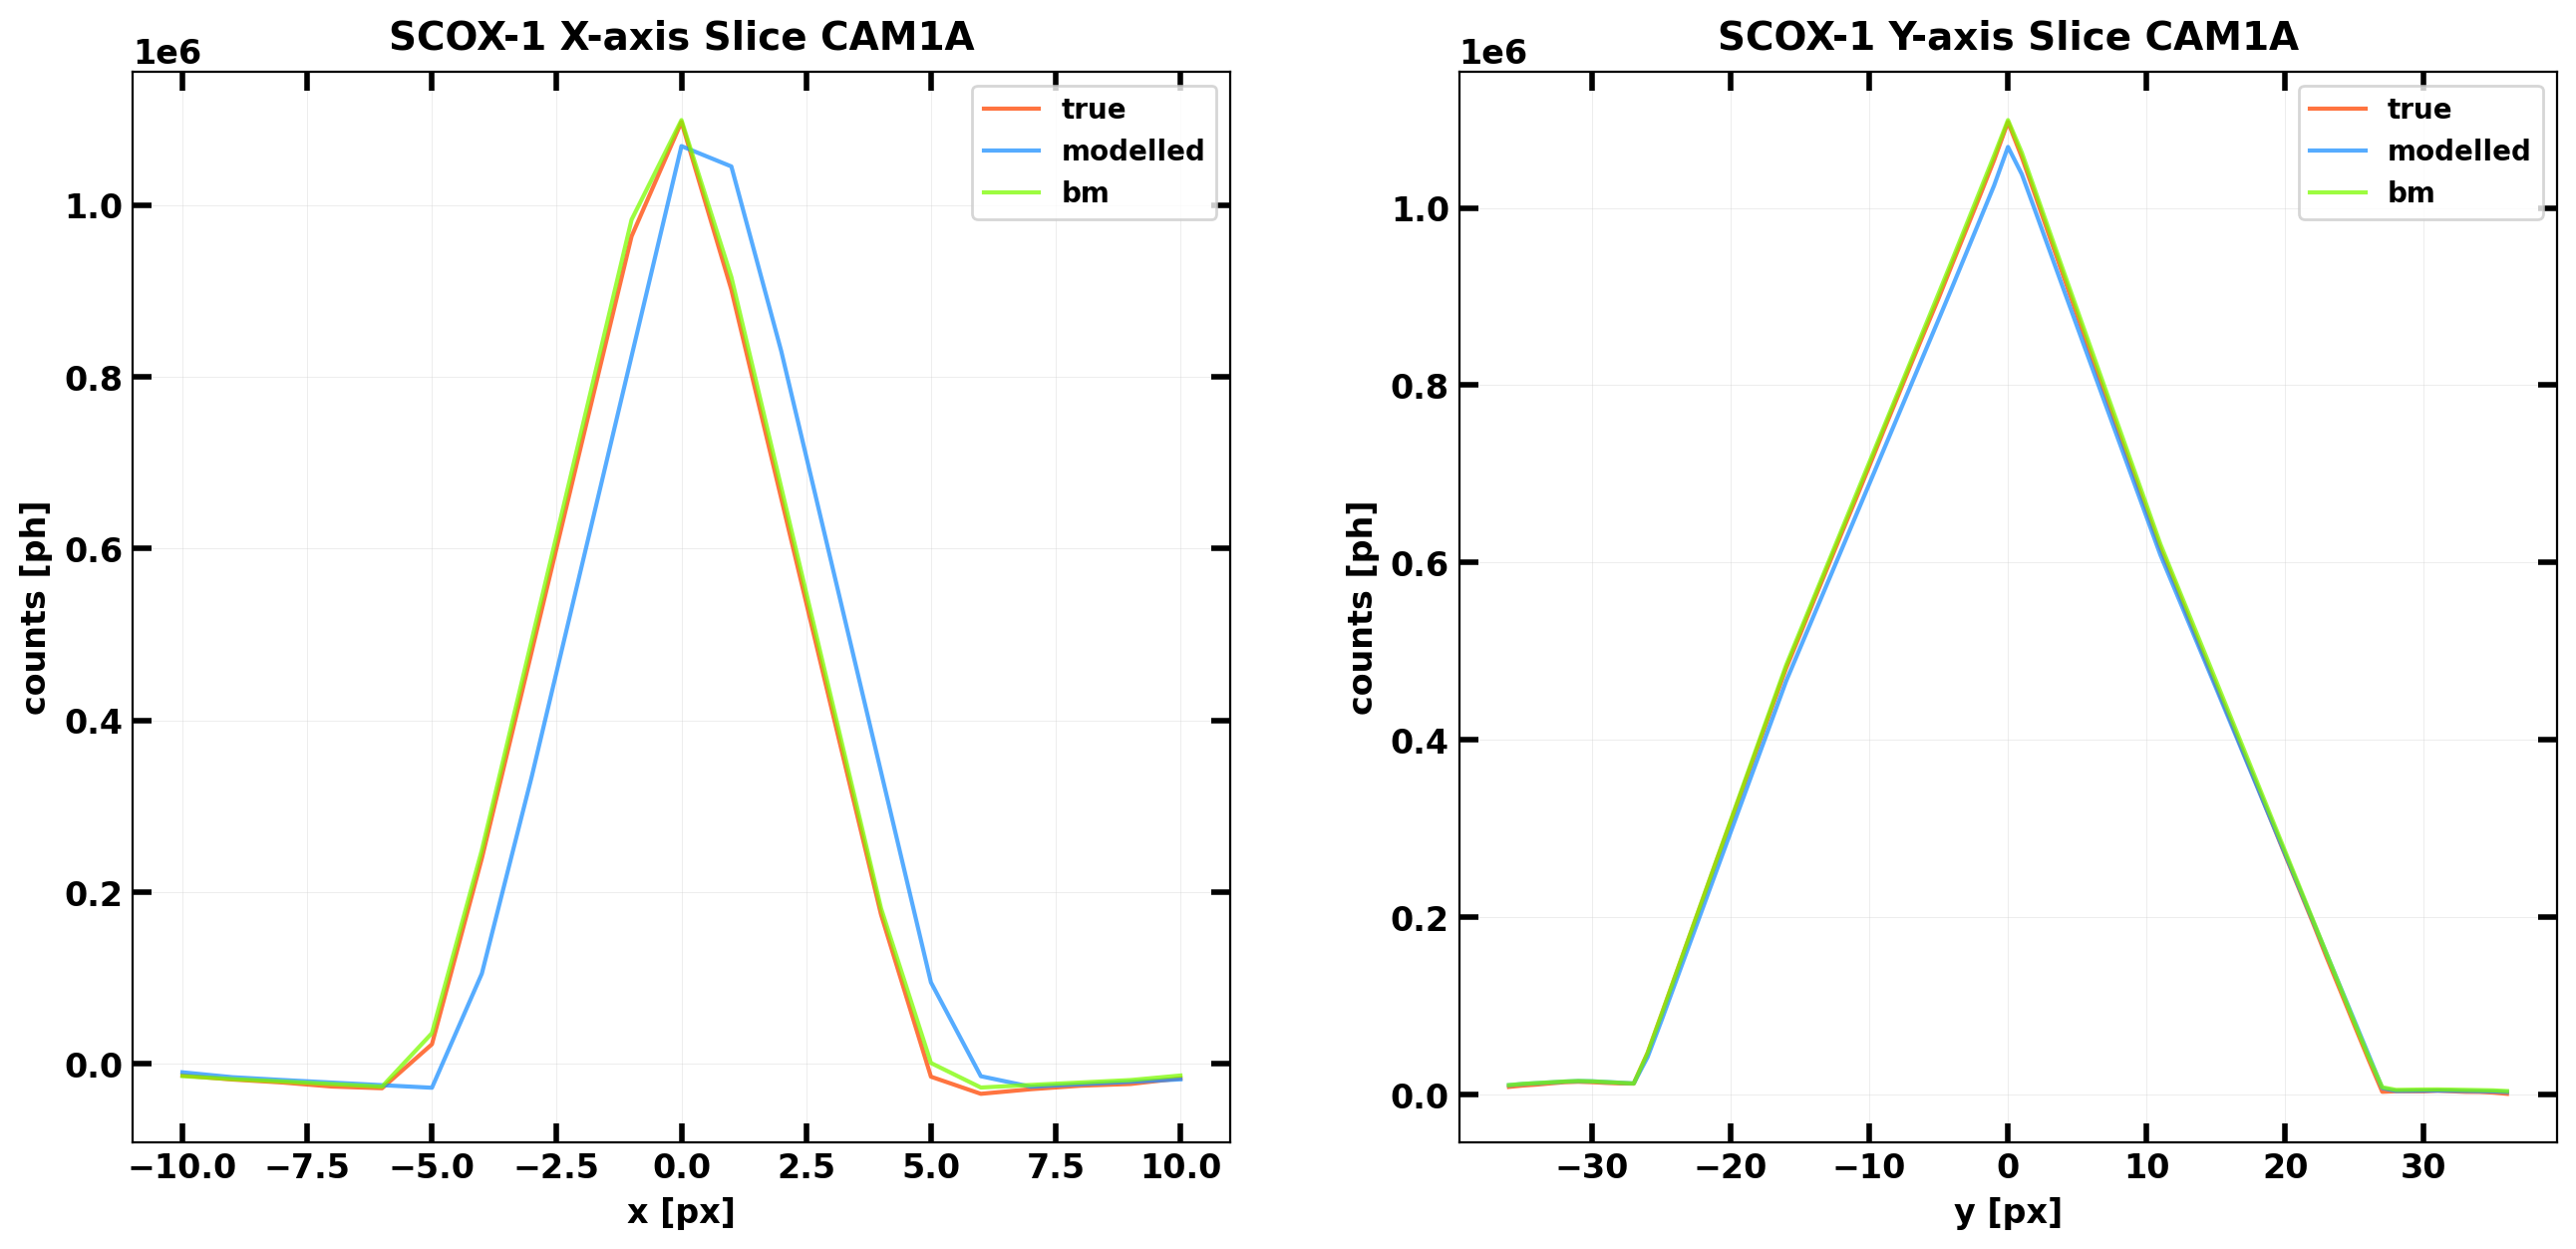

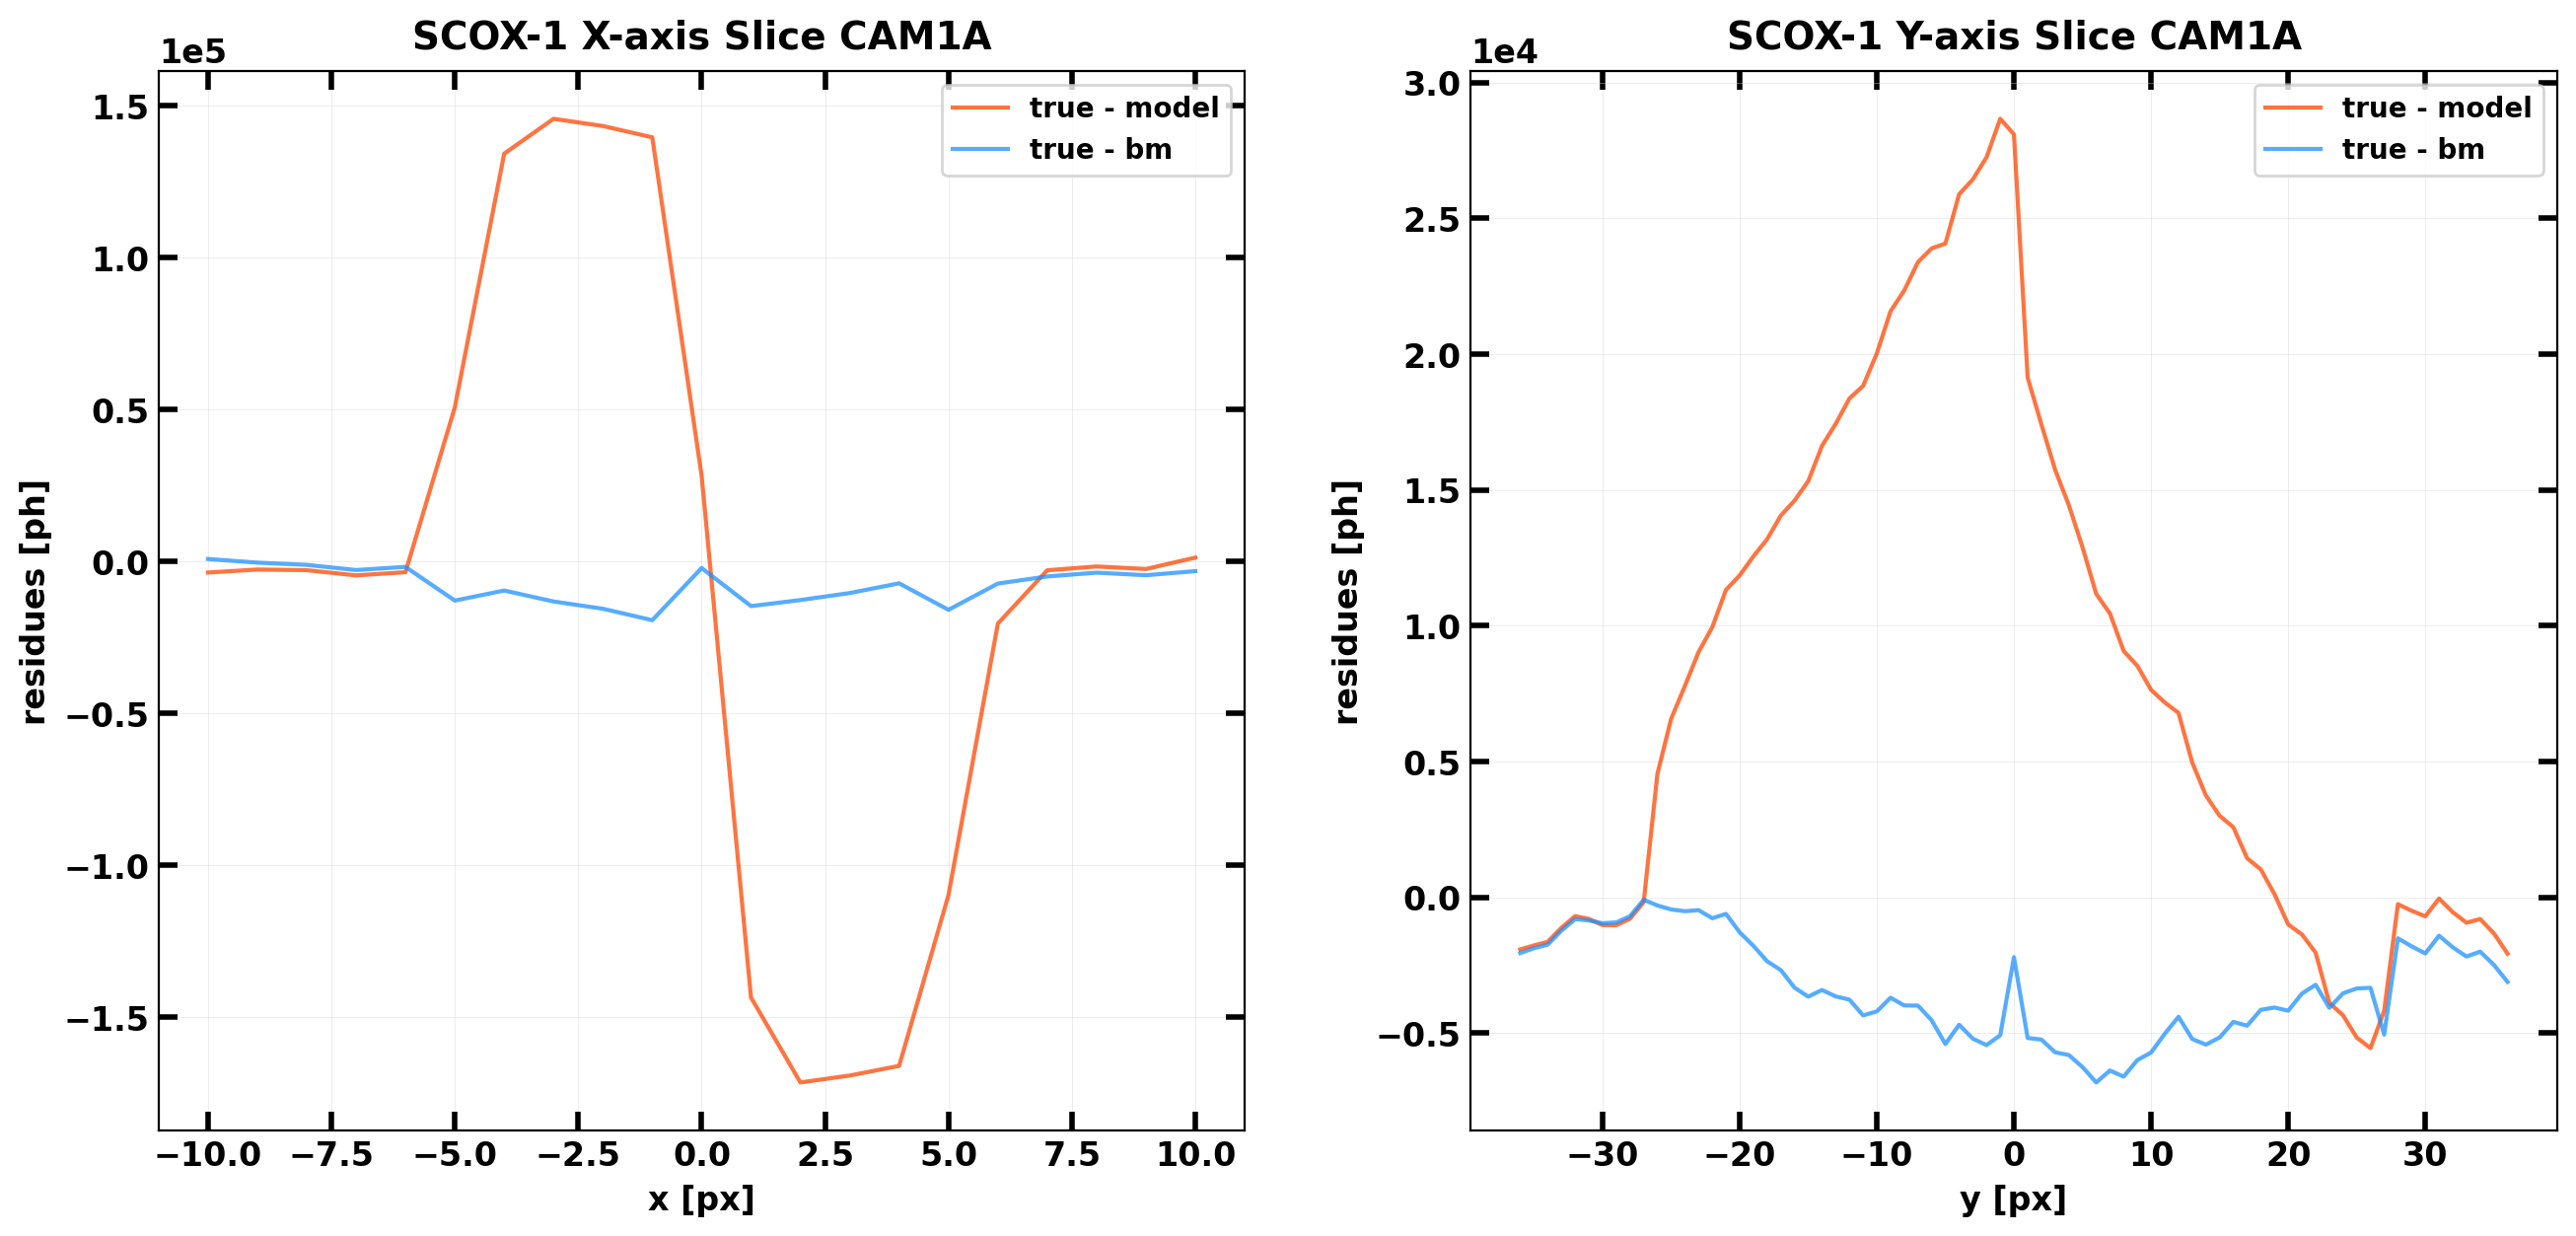

In [ ]:
sdlA = ds.get_data(filepaths[cam_a][dataset])
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])

detector, _ = count(wfm, sdlA.DLdata)
true_sky = decode(wfm, detector)

sources = extract_catalogue_angular_coords(catalogueA, sdlA, wfm)
scox1 = sources[(sources['ID'] == source_ID)]

thetax, thetay = np.array(scox1['THETAX'])[0], np.array(scox1['THETAY'])[0]
print(f'\nSCOX-1 angular coords: {thetax, thetay}\n')
shiftx, shifty = map(
    lambda x: angle2shift(wfm, x),
    (thetax, thetay),
)
i, j = shift2pos(wfm, shiftx, shifty)
fluence = 1.02 * np.max(true_sky[i - 5 : i + 6, j - 5 : j + 6])

pxdimy, pxdimx = (
    wfm.specs['mask_deltay'] / wfm.upscale_f.y,
    wfm.specs['mask_deltax'] / wfm.upscale_f.x,
)


scox1_model = model_sky(
    camera=wfm,
    shift_x=shiftx, # - 0.65 * pxdimx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
scox1_bm_model = bm_sky(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
res_sky = true_sky - scox1_model

crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
ds.slices_plot(
    sky=(true_sky, scox1_model, scox1_bm_model),
    pos=(i, j),
    crp=crp,
    source='scox-1',
    labels=('true', 'modelled', 'bm'),
    cameraID=cam_a,
    #save_to=is_img(save_to, f'skyslice_{tx_}{ty_}_sameVignettingSign'),
)
ds.slices_plot(
    sky=(res_sky, true_sky - scox1_bm_model),
    pos=(i, j),
    crp=crp,
    source='scox-1',
    ylabel='residues [ph]',
    labels=('true - model', 'true - bm'),
    cameraID=cam_a,
    #save_to=is_img(save_to, f'skyslice_res_{tx_}{ty_}_sameVignettingSign'),
)


SCOX-1 angular coords: (np.float64(21.025135698738186), np.float64(-12.202274809914616))



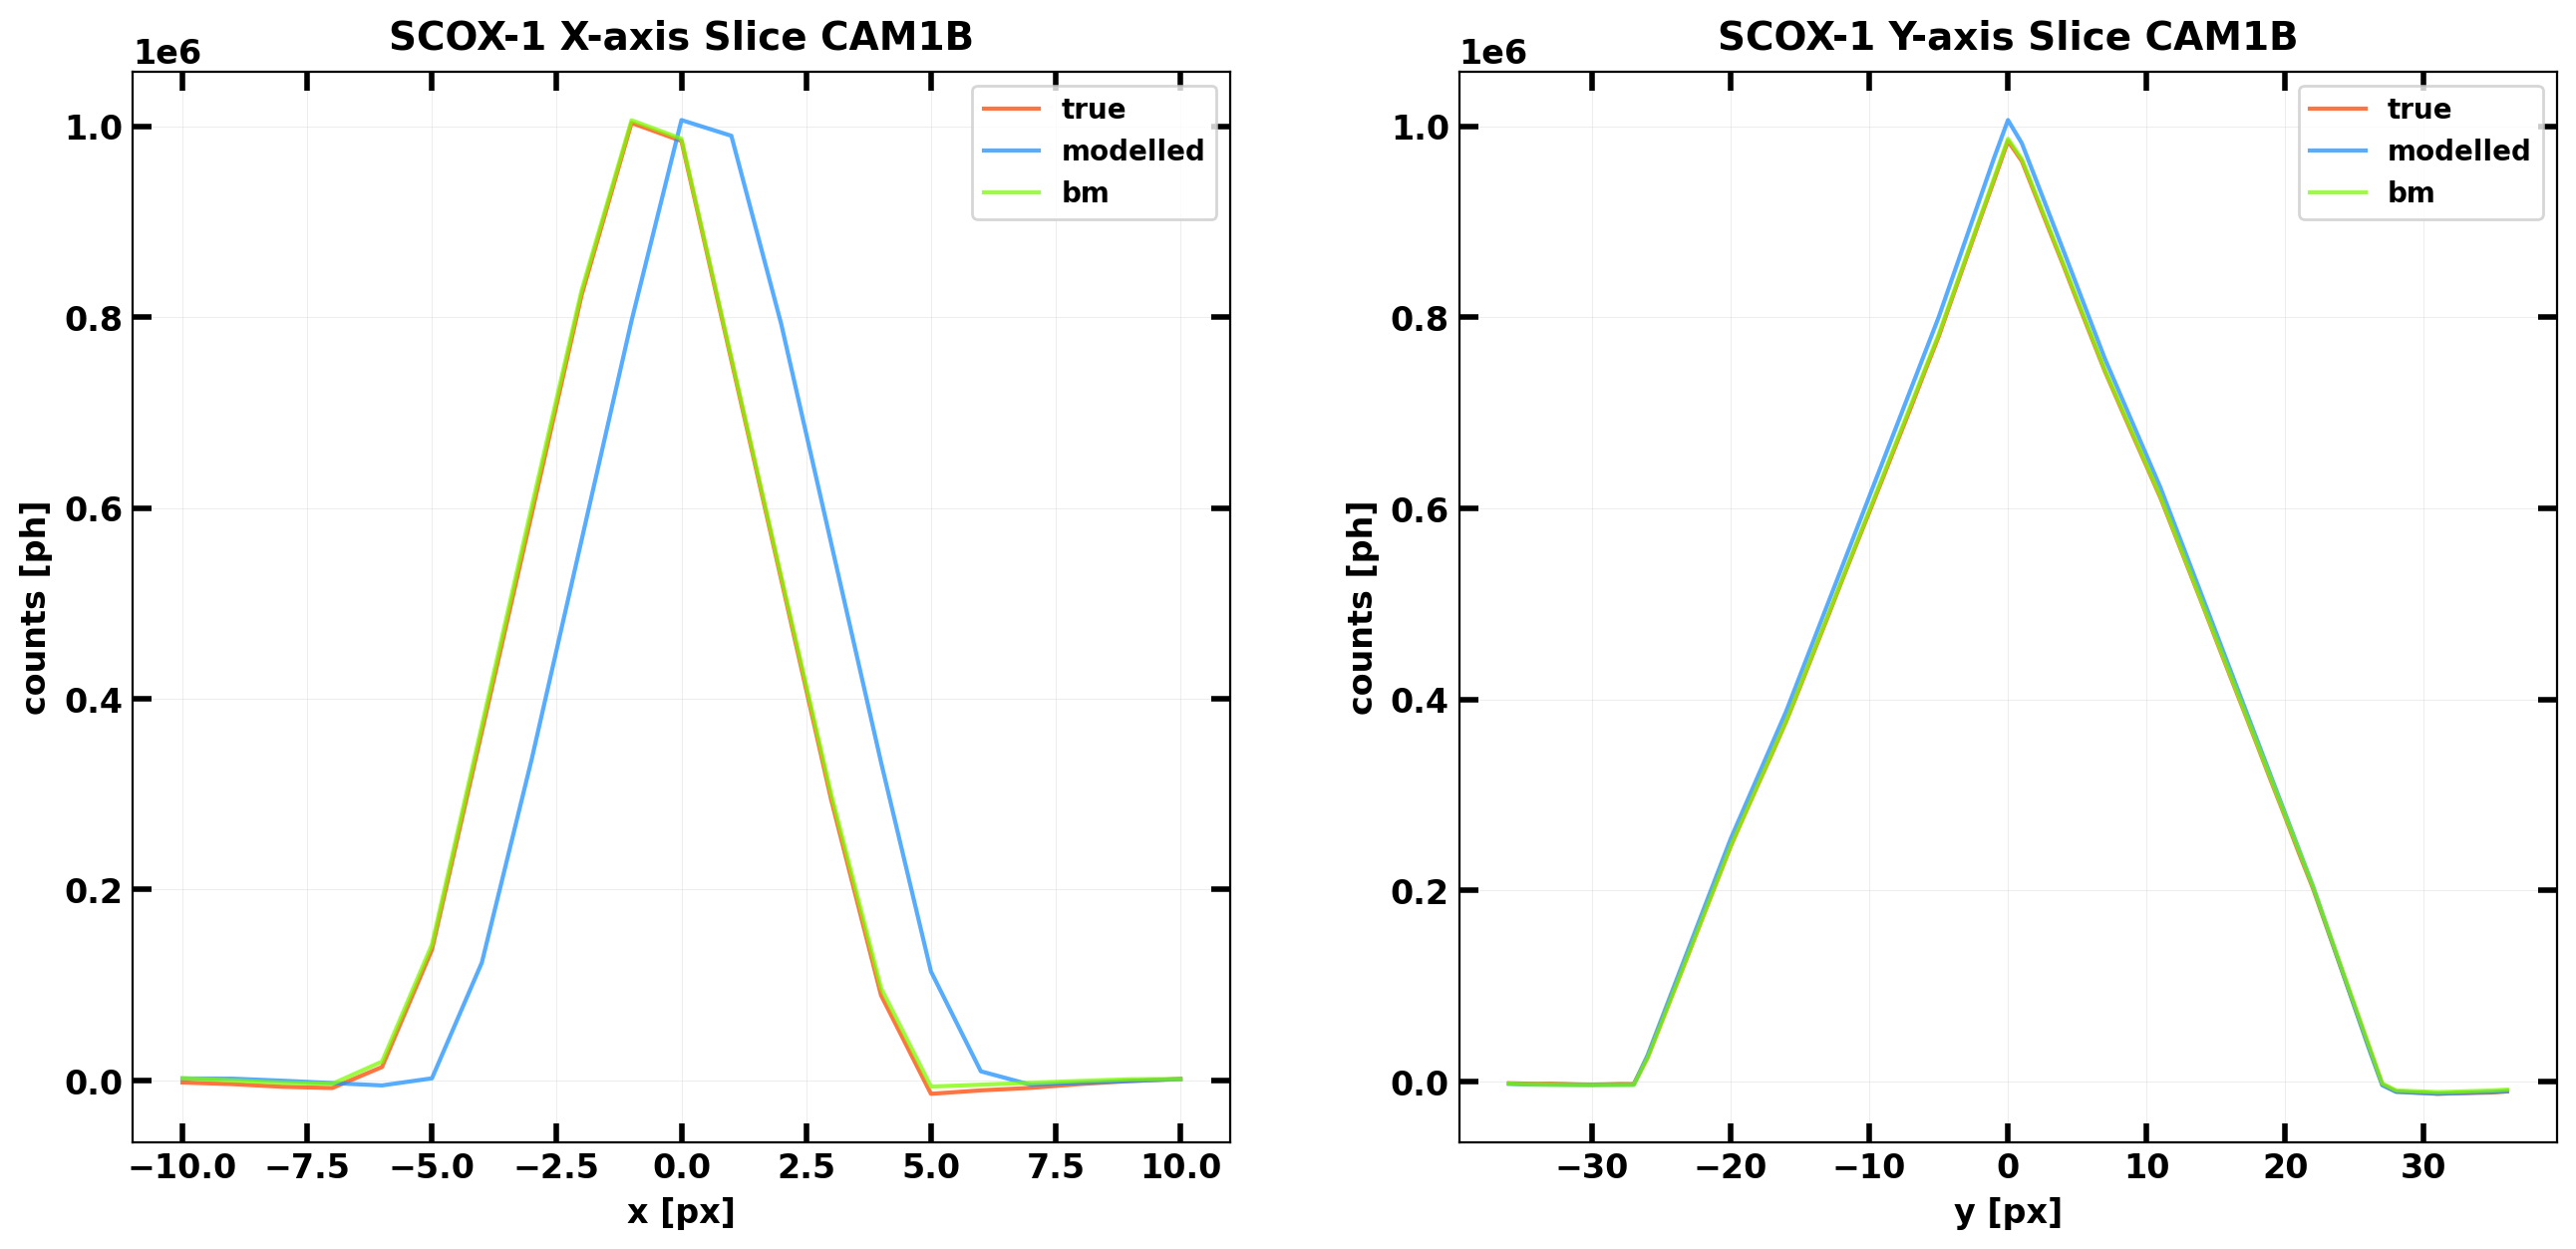

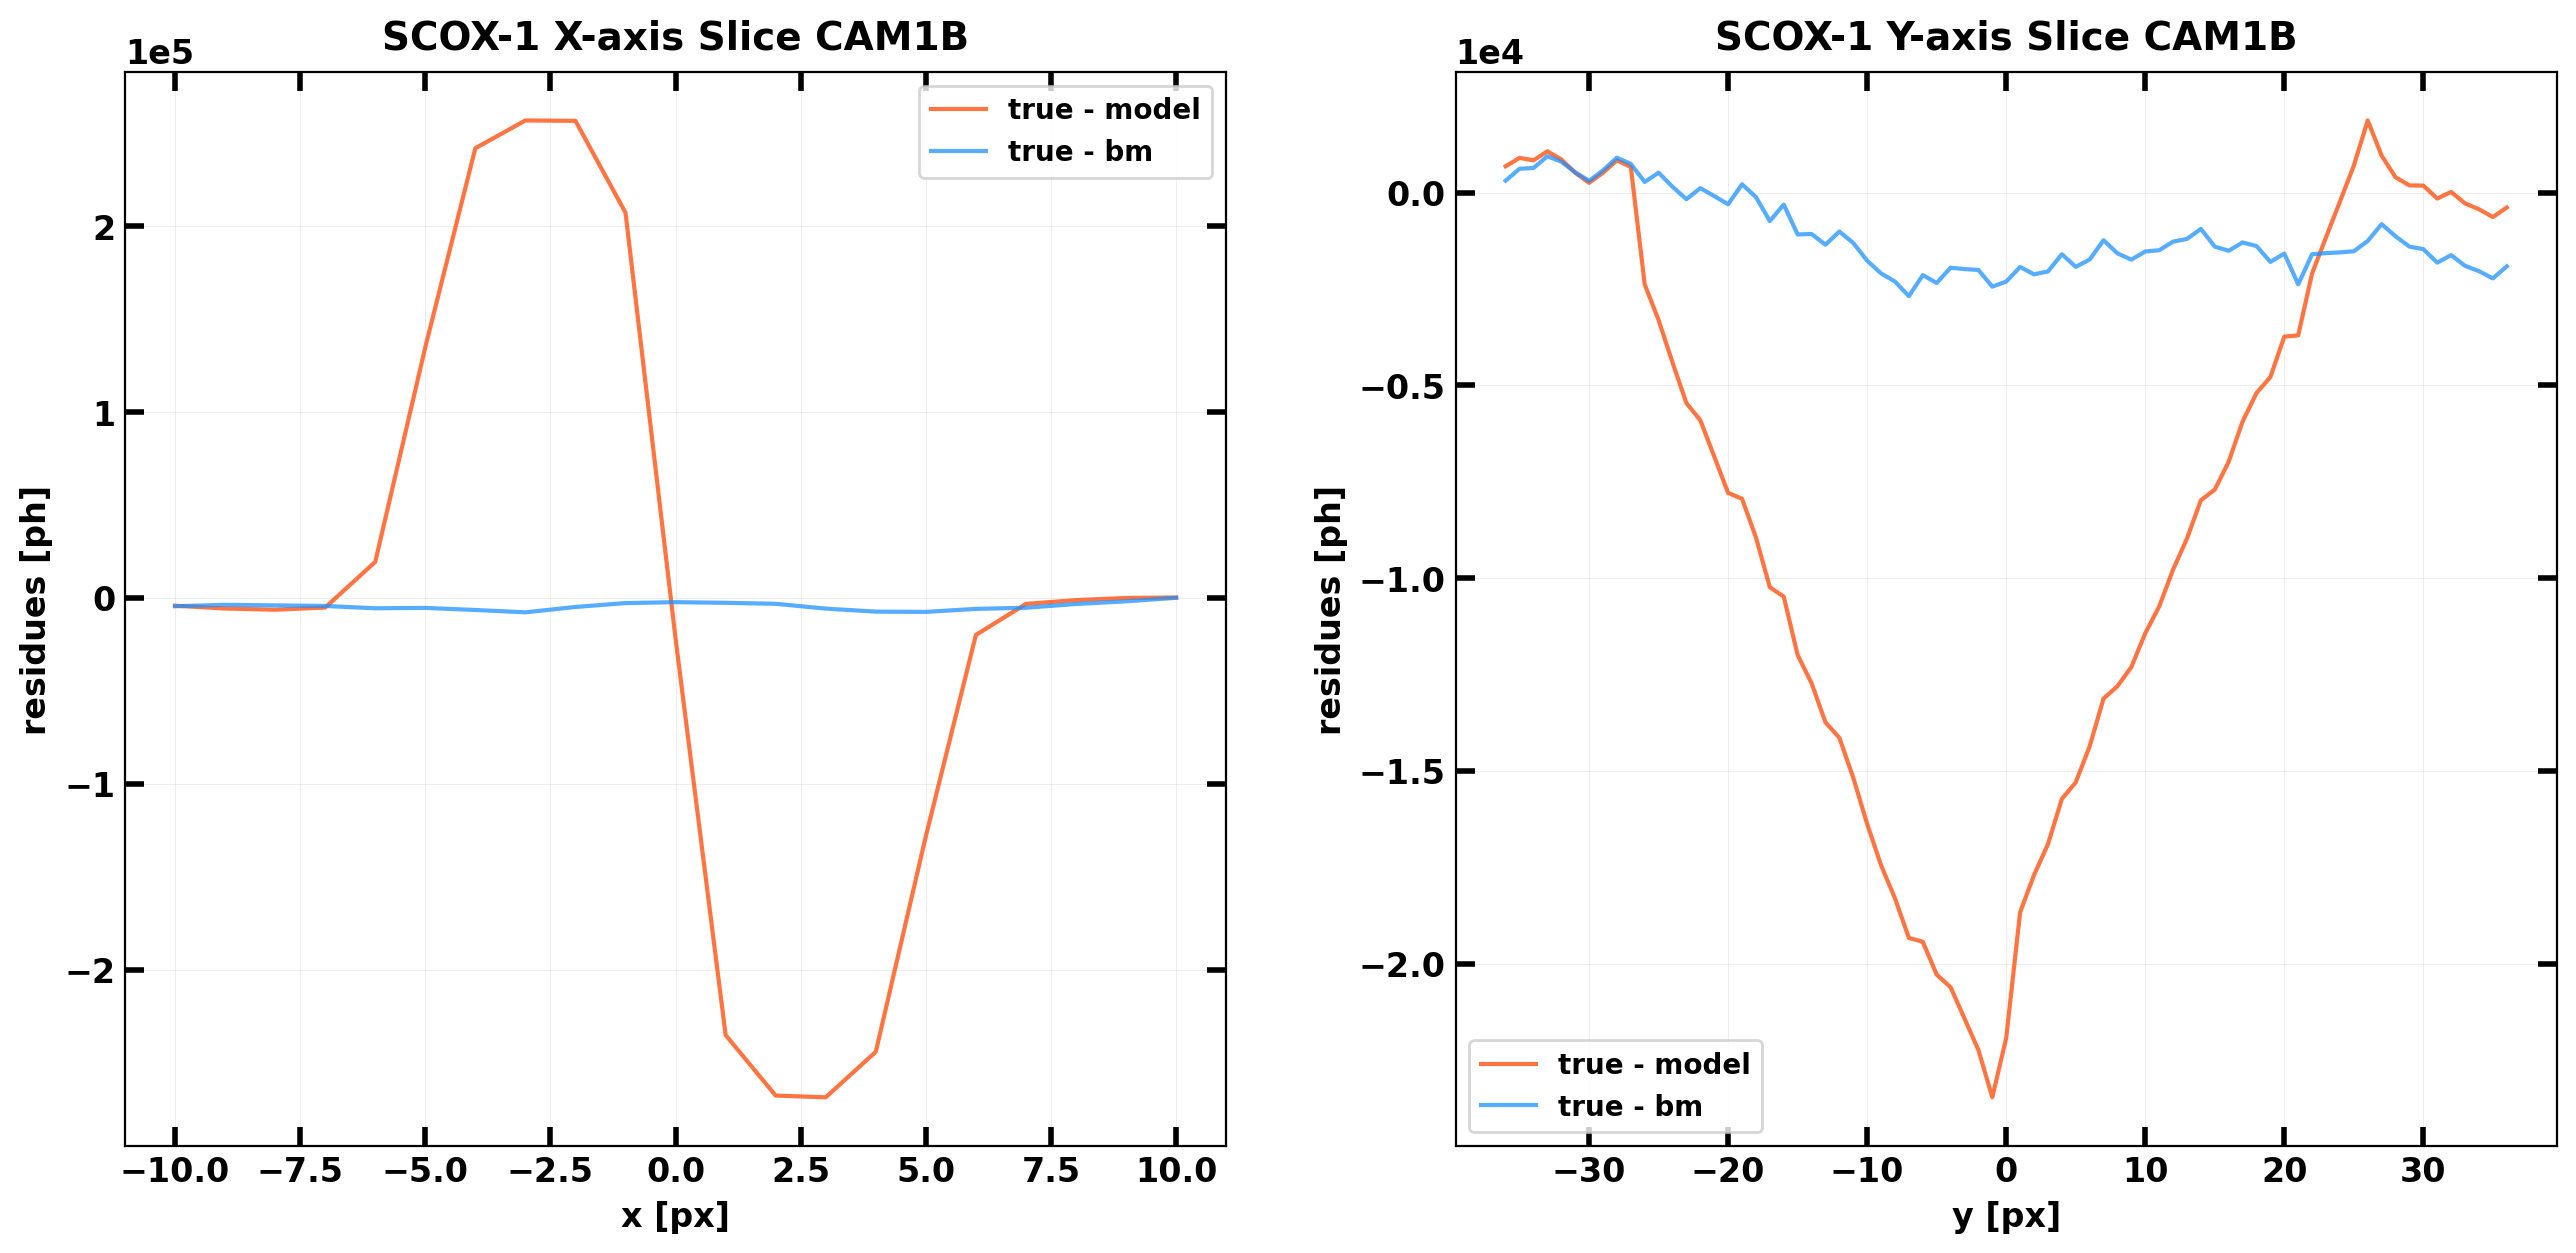

In [ ]:
sdlB = ds.get_data(filepaths[cam_b][dataset])
catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

detector, _ = count(wfm, sdlB.DLdata)
true_sky = decode(wfm, detector)

sources = extract_catalogue_angular_coords(catalogueB, sdlB, wfm)
scox1 = sources[(sources['ID'] == source_ID)]

thetax, thetay = np.array(scox1['THETAX'])[0], np.array(scox1['THETAY'])[0]
print(f'\nSCOX-1 angular coords: {thetax, thetay}\n')
shiftx, shifty = map(
    lambda x: angle2shift(wfm, x),
    (thetax, thetay),
)
i, j = shift2pos(wfm, shiftx, shifty)
fluence = 1.01 * np.max(true_sky[i - 5 : i + 6, j - 5 : j + 6])

pxdimy, pxdimx = (
    wfm.specs['mask_deltay'] / wfm.upscale_f.y,
    wfm.specs['mask_deltax'] / wfm.upscale_f.x,
)

scox1_model = model_sky(
    camera=wfm,
    shift_x=shiftx, # - 1.03 * pxdimx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
scox1_bm_model = bm_sky(
    camera=wfm,
    shift_x=shiftx,
    shift_y=shifty,
    fluence=fluence,
    vignetting=VIGNETTING,
    psfy=PSFY,
)
res_sky = true_sky - scox1_model

crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
ds.slices_plot(
    sky=(true_sky, scox1_model, scox1_bm_model),
    pos=(i, j),
    crp=crp,
    source='scox-1',
    labels=('true', 'modelled', 'bm'),
    cameraID=cam_b,
    #save_to=is_img(save_to, f'skyslice_{tx_}{ty_}_sameVignettingSign'),
)
ds.slices_plot(
    sky=(res_sky, true_sky - scox1_bm_model),
    pos=(i, j),
    crp=crp,
    source='scox-1',
    ylabel='residues [ph]',
    labels=('true - model', 'true - bm'),
    cameraID=cam_b,
    #save_to=is_img(save_to, f'skyslice_res_{tx_}{ty_}_sameVignettingSign'),
)